### Astrostatistic Lecture 18

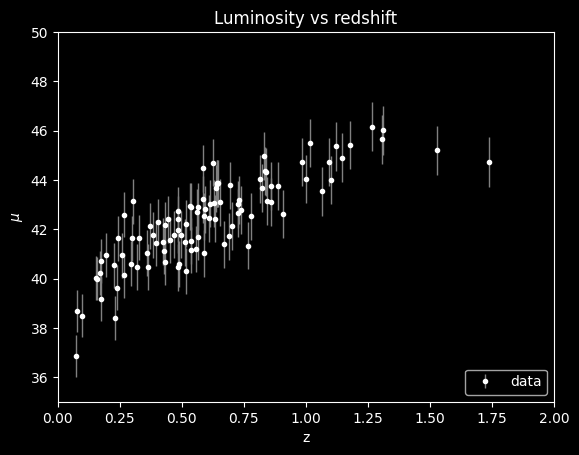

In [41]:
#capire che alpha usare su tutta sta roba se tenere 0.1 o mettere dmu (per ora uso y=mu_sample, alpha=dmu**2), in caso contrario mettere alpha=0.1**2 e y=np.random.normal(mu_sample, 0.1)
from astroML.datasets import generate_mu_z
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from sklearn.gaussian_process import GaussianProcessRegressor, kernels
import numpy as np
from tqdm import tqdm
from scipy import stats
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

#just plot of the data 
plt.errorbar(z_sample, mu_sample, dmu, fmt='.', ecolor='gray', lw=1,label='data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

/home/ricca/astrostat/astrostatistics_bicocca_2026/venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


best-fit theta = 0.6931471805599453


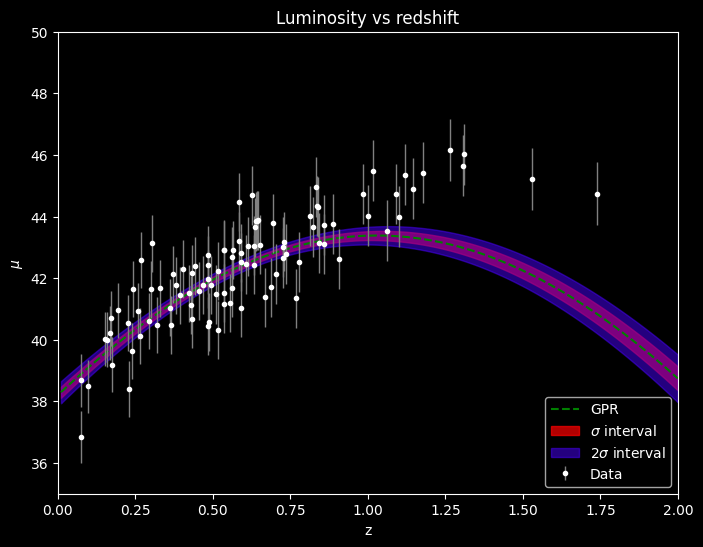

In [42]:
#try to fit the data with GPR
#we make the function pass into the data points
x = z_sample
x_test = np.linspace(0.01, 2, 10000)
y=mu_sample  #points in a distribution around the data

kernel = kernels.RBF(1, (0.01, 2.0))
gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu**2, random_state=0)  #create the GPR

gp.fit(x[:, None], y)   #fit the GPR
predic, predic_err = gp.predict(x_test[:, None], 
                         return_std=True)          #predict

print("best-fit theta =", gp.kernel_.theta[0])

plt.figure(figsize=(8, 6))  #plot the GPR with confidence levels and the data 
plt.plot(x_test, predic, linestyle='dashed', color='green', label='GPR')
plt.fill_between(x_test, predic - predic_err, predic + predic_err, 
                color="#FF0000FF", alpha=0.7, label=r'$\sigma$ interval')
plt.fill_between(x_test, predic - 2 * predic_err, predic + 2 * predic_err, 
                color="#4800FF", alpha=0.5, label=r'2$\sigma$ interval')
plt.errorbar(z_sample, mu_sample , dmu, fmt='.', ms=6, ecolor='gray', lw=1, label='Data', color='white')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Luminosity vs redshift")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

 22%|██▏       | 22/100 [00:00<00:00, 110.19it/s]

CV error = 2.1990327058040804
train error = 0.6899568865610051
CV error = 2.171134464636285
train error = 0.6920212394164096
CV error = 2.1420614377852503
train error = 0.6934321755583147
CV error = 2.111216318271778
train error = 0.6940802725600407
CV error = 2.078043461203685
train error = 0.6939040319178238
CV error = 2.042110985113038
train error = 0.6929006961818077
CV error = 2.0032059893550587
train error = 0.6911358592633737
CV error = 1.9614146853261398
train error = 0.6887457048635147
CV error = 1.9171566094860402
train error = 0.6859280124946369
CV error = 1.871145126829703
train error = 0.6829213213748124
CV error = 1.8242650751582423
train error = 0.6799729138942479
CV error = 1.7773990690071426
train error = 0.6772999584681378
CV error = 1.731273172254174
train error = 0.675057547806637
CV error = 1.6863934387857598
train error = 0.6733319102800841
CV error = 1.6431015025459914
train error = 0.6721636222664829
CV error = 1.6017132753833774
train error = 0.6715831701107703

 48%|████▊     | 48/100 [00:00<00:00, 118.79it/s]

CV error = 1.3924580167870686
train error = 0.6841397710559776
CV error = 1.3735778829270817
train error = 0.6873994634921381
CV error = 1.3569652545634046
train error = 0.6910043985187991
CV error = 1.3423992038562034
train error = 0.6950805768280889
CV error = 1.3294599537928864
train error = 0.699730003112417
CV error = 1.3175860775937442
train error = 0.7049905273009156
CV error = 1.3061949130423072
train error = 0.710805928246914
CV error = 1.294806780918453
train error = 0.7170211256209683
CV error = 1.2831224783143746
train error = 0.7234018926595146
CV error = 1.2710891309367645
train error = 0.7297091340920194
CV error = 1.2589289305720652
train error = 0.7358084447840397
CV error = 1.24696988937402
train error = 0.7416729483893437
CV error = 1.235342175660088
train error = 0.7472506169480362
CV error = 1.2239038050744089
train error = 0.7524067190436983
CV error = 1.2125513552750555
train error = 0.7570847705058034
CV error = 1.2015806560340863
train error = 0.761516296500152

 60%|██████    | 60/100 [00:00<00:00, 118.66it/s]

CV error = 1.137209893307999
train error = 0.8248465050015211
CV error = 1.1271605463942964
train error = 0.8274919756706737
CV error = 1.116420402704025
train error = 0.8299027183686046
CV error = 1.106424974105834
train error = 0.832761370055044
CV error = 1.0987055690757022
train error = 0.8366635589863256
CV error = 1.094340980466042
train error = 0.8418987624189409
CV error = 1.093531710392145
train error = 0.8483106877445618
CV error = 1.0955237749174178
train error = 0.8552991832658148
CV error = 1.098928558424226
train error = 0.861997165928134
CV error = 1.1022539218887297
train error = 0.8675664371525602
CV error = 1.104375070084261
train error = 0.8714713340195697
CV error = 1.1047838227121036
train error = 0.8736115495002122
CV error = 1.1036170825281633
train error = 0.8743019250491282
CV error = 1.1015412797638875
train error = 0.8741636744384994
CV error = 1.0995628277739171
train error = 0.8739918599331057
CV error = 1.0988127994765793
train error = 0.8746320322579153
C

 83%|████████▎ | 83/100 [00:00<00:00, 98.36it/s] 

CV error = 1.184973336112075
train error = 0.95002220420516
CV error = 1.2121069489076368
train error = 0.973635927393093
CV error = 1.2429353806930468
train error = 1.0006716431486915
CV error = 1.277715472750471
train error = 1.0313310649555556
CV error = 1.316857969133372
train error = 1.065927379419986
CV error = 1.3608854649874265
train error = 1.1048616228948276
CV error = 1.4103702567570313
train error = 1.1485792600432032
CV error = 1.4658618258122984
train error = 1.1975154321763788
CV error = 1.5278127632026812
train error = 1.2520367168479127
CV error = 1.5965107887901895
train error = 1.3123859424336395
CV error = 1.672023406772038
train error = 1.3786354005103978
CV error = 1.7541605217525649
train error = 1.4506528061126875
CV error = 1.842458747012562
train error = 1.5280833280788921
CV error = 1.9361890366355556
train error = 1.6103496808401456
CV error = 2.0343867833952554
train error = 1.6966705461553784
CV error = 2.1359009893347567
train error = 1.786095623482232
CV

100%|██████████| 100/100 [00:00<00:00, 103.51it/s]


CV error = 2.4473935537104086
train error = 2.06201822323406
CV error = 2.549222971613901
train error = 2.1527878680267607
CV error = 2.6481048225493184
train error = 2.241218788360827
CV error = 2.7430937996672364
train error = 2.3264430485642
CV error = 2.8334296404623283
train error = 2.407746718637928
CV error = 2.91854387624488
train error = 2.484580342603926
CV error = 2.99805446218569
train error = 2.556558237206545
CV error = 3.071751152910754
train error = 2.6234488218750713
CV error = 3.1395746722132456
train error = 2.6851585375802722
CV error = 3.201592518793462
train error = 2.7417118834594385
CV error = 3.257973795866944
train error = 2.7932298001451086
CV error = 3.308964885103106
train error = 2.8399081784942917


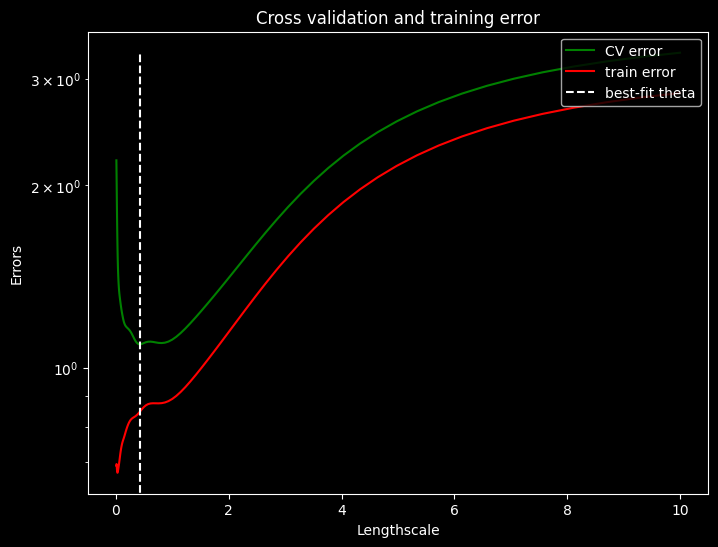

best-fit theta = 0.43287612810830595


In [44]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
# now we need to do a cross validation on the GPR lengthscale

kf = KFold(n_splits=5, shuffle=True, random_state=42)   #use a 5-fold cross validation for the GPR lengthscale
scores=[]
t_scores=[]
lengthscale = np.logspace(-2, 1, 100)

for l in tqdm(lengthscale):     #cycle over the lengthscale
    fold_errors = []
    t_err = []
    for train_idx, test_idx in kf.split(x):     #for each l we do a 5-fold cross validation
        X_train, X_test = x[train_idx], x[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        dmu_train=dmu[train_idx]
        kernel=kernels.RBF(l, length_scale_bounds='fixed')
        gp = GaussianProcessRegressor(kernel=kernel, alpha=dmu_train**2, random_state=0, normalize_y=True)
        gp.fit(X_train[:, None], y_train)
        y_pred = gp.predict(X_test[:, None])
        error = error = np.mean(((y_test - y_pred) / dmu[test_idx])**2)
        fold_errors.append(error)
        train_error = mean_squared_error(y_train, gp.predict(X_train[:, None]))
        t_err.append(train_error)
    scores.append(np.mean(fold_errors))     #append the mean of the errors for test and train sets
    t_scores.append(np.mean(t_err))
    print(f"CV error = {scores[-1]}")
    print(f"train error = {t_scores[-1]}")
best_l = lengthscale[np.argmin(scores)]

plt.figure(figsize=(8, 6))      #plot the cross validation errors and training errors
plt.plot(lengthscale, scores, color='green', label='CV error')
plt.plot(lengthscale, t_scores, color='red', label='train error')
plt.vlines(best_l, 0, np.max(scores), color='white', ls='dashed', lw=1.5, label='best-fit theta')
plt.xlabel("Lengthscale")
plt.ylabel("Errors")
plt.title("Cross validation and training error")
plt.legend(loc='upper right')
plt.yscale('log')
plt.show()

print("best-fit theta =", best_l)     #best-fit lengthscale

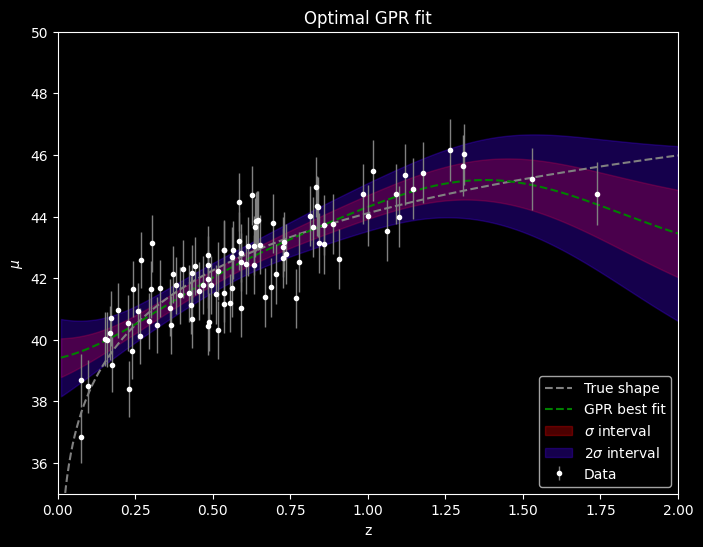

In [48]:
from astropy.cosmology import LambdaCDM

#true model
cosmo = LambdaCDM(H0=71, Om0=0.27, Ode0=1-0.27)
z = np.linspace(0.01, 2, 1000)
mu_true = cosmo.distmod(z)

#best parametern fit and comparison
x = z_sample
x_test = np.linspace(0.01, 2, 10000)
y=mu_sample

kernel = kernels.RBF(length_scale=best_l, length_scale_bounds="fixed")

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=dmu**2,
    normalize_y=True,
    random_state=0
)

gp.fit(x[:, None], y)

predic, predic_err = gp.predict(
    x_test[:, None],
    return_std=True
)

plt.figure(figsize=(8, 6))
plt.plot(z, mu_true, '--', c='gray', label='True shape')
plt.plot(x_test, predic, linestyle='dashed', color='green', label='GPR best fit')
plt.fill_between(x_test, predic - predic_err, predic + predic_err, 
                color="#FF0000FF", alpha=0.3, label=r'$\sigma$ interval')
plt.fill_between(x_test, predic - 2 * predic_err, predic + 2 * predic_err, 
                color="#4800FF", alpha=0.3, label=r'2$\sigma$ interval')
plt.errorbar(z_sample, mu_sample , dmu, fmt='.', ms=6, ecolor='gray', lw=1, label='Data', color='white', zorder=3)
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend(loc='lower right')
plt.title("Optimal GPR fit")
plt.xlim(0,2)
plt.ylim(35,50)
plt.show()

In [ ]:
#now from this fit we can get the pdf of the data and clone them to generate a bigger sample with same characteristics

samples = gp.sample_y(x_test[:, None], 10)

print(samples.shape)
    
